# Random Forest Tuning (Descriptors + Fingerprints)

In [41]:
import numpy as np
import pandas as pd

from rdkit import Chem, RDLogger, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem, MACCSkeys
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.ML.Descriptors import MoleculeDescriptors as md

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_val_score,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

import optuna

## Logging results

In [42]:
# Глобальный список для хранения всех результатов
all_results = []


def log_result(method_name, model_type, n_features, metrics, params=None, stage=None):
    record = {
        "Method": method_name,
        "Model": model_type,
        "Stage": stage,
        "Top_Features": n_features,

        # Метрики
        "Accuracy": metrics.get("Accuracy"),
        "Precision": metrics.get("Precision"),
        "Recall": metrics.get("Recall"),
        "F1": metrics.get("F1"),
        "ROC_AUC": metrics.get("AUC"),
    }

    # Добавляем параметры модели, если есть
    if params is not None:
        for key, value in params.items():
            record[f"Param_{key}"] = value

    all_results.append(record)


def save_results_table(filename="all_results.xlsx"):
    """
    Преобразует global all_results → DataFrame и сохраняет таблицу.
    """
    df = pd.DataFrame(all_results)
    df.to_excel(filename, index=False)
    print(f"Saved full results table to {filename}")
    return df


## Molecule, Descriptor + Fingerprints and Outlier Functions

In [43]:
def molecule_from_smiles(smiles):
    lg = RDLogger.logger()
    # Temporarily silence RDKit logs
    lg.setLevel(RDLogger.CRITICAL)
    try:
        # Extract molecule
        molecule = Chem.MolFromSmiles(smiles, sanitize=True)
        if molecule is None:
            return None, "failed"

        # Remove salts
        clean_molecule = rdMolStandardize.LargestFragmentChooser()
        molecule = clean_molecule.choose(molecule)

        # Sanitize molecule again to reflect changes
        Chem.SanitizeMol(molecule)
        return molecule, "succeed"
    except Exception as e:
        return None, f"error: {e}"
    finally:
        # Re-enable logging afterward
        lg.setLevel(RDLogger.INFO)


def calculate_descriptors(molecule):
    # Get all descriptors (1D/2D)
    descriptor_names = []
    for descriptor, _ in Descriptors._descList:
        descriptor_names.append(descriptor)

    # Use descriptors to calculate values
    calculator = md.MolecularDescriptorCalculator(descriptor_names)
    descriptor_values = calculator.CalcDescriptors(molecule)

    # Create dictionary
    descriptors = dict(zip(descriptor_names, descriptor_values))
    return descriptors


def compute_iqr_limits(df, factor=1.5):
    # Calculate IQR limits
    limits = {}
    for col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        # If IQR is 0 - column is too flat - skip
        if iqr == 0 or np.isnan(iqr):
            continue

        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        limits[col] = (lower, upper)
    return limits


def apply_iqr_limits(df, limits):
    # Apply the limits
    df_clipped = df.copy()
    for col, (lower, upper) in limits.items():
        df_clipped[col] = df_clipped[col].clip(lower, upper)
    return df_clipped


def bitvect_to_dict(fp, prefix):
    # Convert bit vector to dictionary (create features)
    n_bits = fp.GetNumBits()
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    features = {}
    for i, v in enumerate(arr):
        features[f"{prefix}_{i}"] = int(v)
    return features


def calculate_fingerprints(mol):
    RDLogger.DisableLog('rdApp.*')
    # Calculate Morgan, RDKit, MACCS, AtomPair and Topological Torsion fingerprint
    feats = {}
    if mol is None:
        return feats

    # Morgan (ECFP) fingerprint
    morgan_bits = 2048
    morgan_radius = 2
    fp_morgan = rdMolDescriptors.GetMorganFingerprintAsBitVect(
        mol, radius=morgan_radius, nBits=morgan_bits
    )
    feats.update(bitvect_to_dict(fp_morgan, f"Morgan{morgan_radius}_{morgan_bits}"))

    # RDKit topological fingerprint
    rdk_bits = 2048
    fp_rdk = Chem.RDKFingerprint(mol, fpSize=rdk_bits)
    feats.update(bitvect_to_dict(fp_rdk, f"RDK_{rdk_bits}"))

    # MACCS keys (167 bits)
    fp_maccs = MACCSkeys.GenMACCSKeys(mol)
    feats.update(bitvect_to_dict(fp_maccs, "MACCS"))

    RDLogger.EnableLog('rdApp.*')

    return feats

## Dataset Processing

In [44]:
# Configuration
ORIG_DATASET = "in_vitro_corrosion.xlsx"
SKIP_ROWS = 1
SMILES_COL = "SMILES code"
TARGET_COL = "Corrosion"
FULL_OUTPUT_DATASET = "in_vitro_corrosion_processed.xlsx"

# Outputs
TRAIN_X_CSV = "in_vitro_corrosion_x_train.csv"
TEST_X_CSV = "in_vitro_corrosion_x_test.csv"
TRAIN_Y_CSV = "in_vitro_corrosion_y_train.csv"
TEST_Y_CSV = "in_vitro_corrosion_y_test.csv"

# Near constant threshold - tolerance
SIMILARITY_THRESHOLD = 0.65
# Correlation threshold
CORRELATION_THRESHOLD = 0.60

dataset = pd.read_excel(ORIG_DATASET, engine="openpyxl", skiprows=SKIP_ROWS)

# --- CLEANING ---
dataset.columns = dataset.columns.str.strip()
dataset = dataset.loc[:, ~dataset.columns.str.contains("^Unnamed")]
dataset = dataset.dropna(subset=["Corrosion"])

# clean target
dataset[TARGET_COL] = dataset[TARGET_COL].astype(str).str.strip()
dataset[TARGET_COL] = dataset[TARGET_COL].replace({
    "C": 1,
    "NC": 0
})

print(dataset.columns)
print(dataset[TARGET_COL].value_counts())

descriptor_rows = []
state_molecules = []
molecules = []

for smiles in dataset[SMILES_COL].astype(str):
    molecule, state = molecule_from_smiles(smiles)
    state_molecules.append(state)
    molecules.append(molecule)

    if molecule is None:
        descriptor_rows.append({})
        continue

    # 1D/2D RDKit descriptors
    desc_feats = calculate_descriptors(molecule)

    # Calculate Morgan, RDKit, MACCS, AtomPair and Topological Torsion fingerprint
    fp_feats = calculate_fingerprints(molecule)

    # Merge both dicts into one feature row
    all_feats = {**desc_feats, **fp_feats}
    descriptor_rows.append(all_feats)

# Convert list of dictionaries into dataframe
descriptor_data_all = pd.DataFrame(descriptor_rows)

# Keep everything + status
output = pd.concat(
    [dataset.reset_index(drop=True), descriptor_data_all.reset_index(drop=True)],
    axis=1
)
output["MoleculeStatus"] = state_molecules

# Output whole dataset with descriptors and state
with pd.ExcelWriter(FULL_OUTPUT_DATASET, engine="openpyxl") as writer:
    output.to_excel(writer, index=False, sheet_name="Descriptors")

print(f"Full - Rows: {len(output)}/Columns: {output.shape[1]}")
print(output.head().to_string(index=False))

# Drop failed molecules - boolean array
molecules_right = []
for molecule in molecules:
    if molecule is not None:
        molecules_right.append(True)
    else:
        molecules_right.append(False)
if not any(molecules_right):
    raise ValueError("No valid molecules after SMILES parsing.")

dataset_ok = dataset.loc[molecules_right].reset_index(drop=True)
descriptor_ok = descriptor_data_all.loc[molecules_right].reset_index(drop=True)

# Target
# y_full = dataset_ok[TARGET_COL].astype(int)
y_full = dataset_ok[TARGET_COL]

# Take only numeric descriptor columns
X_full = descriptor_ok.select_dtypes(include=[np.number]).copy()
for column in X_full.columns:
    X_full[column] = X_full[column].replace([np.inf, -np.inf], np.nan)

# Drop columns that are entirely NaN
all_nan_cols = X_full.columns[X_full.isna().all()].tolist()
if all_nan_cols:
    print(f"Dropping {len(all_nan_cols)} NaN columns.")
    X_full = X_full.drop(columns=all_nan_cols)

# CHECK
print("Target dtype:", dataset[TARGET_COL].dtype)
print(dataset[TARGET_COL].value_counts())

# Split dataset - train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

# Calculate medians for each column in train only
train_medians = X_train.median(numeric_only=True)

# Fill missing values in both train and test using those medians
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# Compute constants on train only
constant_cols = []
for col in X_train.columns:
    top_freq = X_train[col].value_counts(normalize=True, dropna=False).max()
    if top_freq >= SIMILARITY_THRESHOLD:
        constant_cols.append(col)

# Drop from train and apply same drop to test
if constant_cols:
    X_train = X_train.drop(columns=constant_cols)
    X_test = X_test.drop(columns=constant_cols)
    print(f"Dropped {len(constant_cols)} constant/almost-constant columns.")

# Compute absolute correlation matrix on training data
corr_matrix = X_train.corr().abs()
# Keep only upper triangle of the matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Find columns to drop - correlation
high_corr_cols = []
for col in upper.columns:
    if any(upper[col] > CORRELATION_THRESHOLD):
        high_corr_cols.append(col)

# Drop from both train and test
if high_corr_cols:
    X_train = X_train.drop(columns=high_corr_cols)
    X_test = X_test.drop(columns=high_corr_cols)
    print(f"Dropped {len(high_corr_cols)} highly correlated columns.")

# Compute IQR limits on training data
iqr_limits = compute_iqr_limits(X_train, factor=1.5)

# Apply limits to both train and test sets
X_train = apply_iqr_limits(X_train, iqr_limits)
X_test = apply_iqr_limits(X_test, iqr_limits)

# Scaling not necessary for all models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train.to_csv(TRAIN_X_CSV, index=False)
X_test.to_csv(TEST_X_CSV, index=False)
y_train.to_csv(TRAIN_Y_CSV, index=False, header=[TARGET_COL])
y_test.to_csv(TEST_Y_CSV, index=False, header=[TARGET_COL])

C:\Users\sirad\AppData\Local\Temp\ipykernel_40816\2945340289.py:28: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset[TARGET_COL] = dataset[TARGET_COL].replace({


Index(['Name', 'IUPAC name', 'CAS registry number', 'Structure', 'Corrosion',
       'SMILES code', 'Sources', 'Note'],
      dtype='object')
Corrosion
0    94
1    63
Name: count, dtype: int64
Full - Rows: 157/Columns: 4489
                         Name                                  IUPAC name CAS registry number  Structure  Corrosion                  SMILES code Sources Note  MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex      qed       SPS   MolWt  HeavyAtomMolWt  ExactMolWt  NumValenceElectrons  NumRadicalElectrons  MaxPartialCharge  MinPartialCharge  MaxAbsPartialCharge  MinAbsPartialCharge  FpDensityMorgan1  FpDensityMorgan2  FpDensityMorgan3  BCUT2D_MWHI  BCUT2D_MWLOW  BCUT2D_CHGHI  BCUT2D_CHGLO  BCUT2D_LOGPHI  BCUT2D_LOGPLOW  BCUT2D_MRHI  BCUT2D_MRLOW   AvgIpc  BalabanJ    BertzCT     Chi0    Chi0n    Chi0v     Chi1    Chi1n    Chi1v    Chi2n    Chi2v    Chi3n    Chi3v    Chi4n    Chi4v  HallKierAlpha        Ipc   Kappa1   Kappa2   Kappa3  LabuteASA  PE

In [45]:
X_train.shape[1]+X_test.shape[1]

54

In [46]:
X_train.shape[0]+X_test.shape[0]

157

In [47]:
X_test.shape[0]

32

## Base Model Train

In [48]:
from sklearn.ensemble import RandomForestClassifier

# Base Random Forest model
base_model = RandomForestClassifier(
    n_estimators=X_train.shape[1],
    random_state=42,
    class_weight="balanced"
)

# Train
base_model.fit(X_train, y_train)

# Predict
y_pred = base_model.predict(X_test)
y_prob = base_model.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\nRandom Forest performance:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 score:  {f1:.4f}")
print(f"ROC AUC:   {auc:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))


Random Forest performance:
Accuracy:  0.7812
Precision: 0.8000
Recall:    0.6154
F1 score:  0.6957
ROC AUC:   0.7895

Classification report:
              precision    recall  f1-score   support

           0      0.773     0.895     0.829        19
           1      0.800     0.615     0.696        13

    accuracy                          0.781        32
   macro avg      0.786     0.755     0.762        32
weighted avg      0.784     0.781     0.775        32



## Feature Selection

C:\Users\sirad\AppData\Local\Temp\ipykernel_40816\4064747932.py:50: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train)


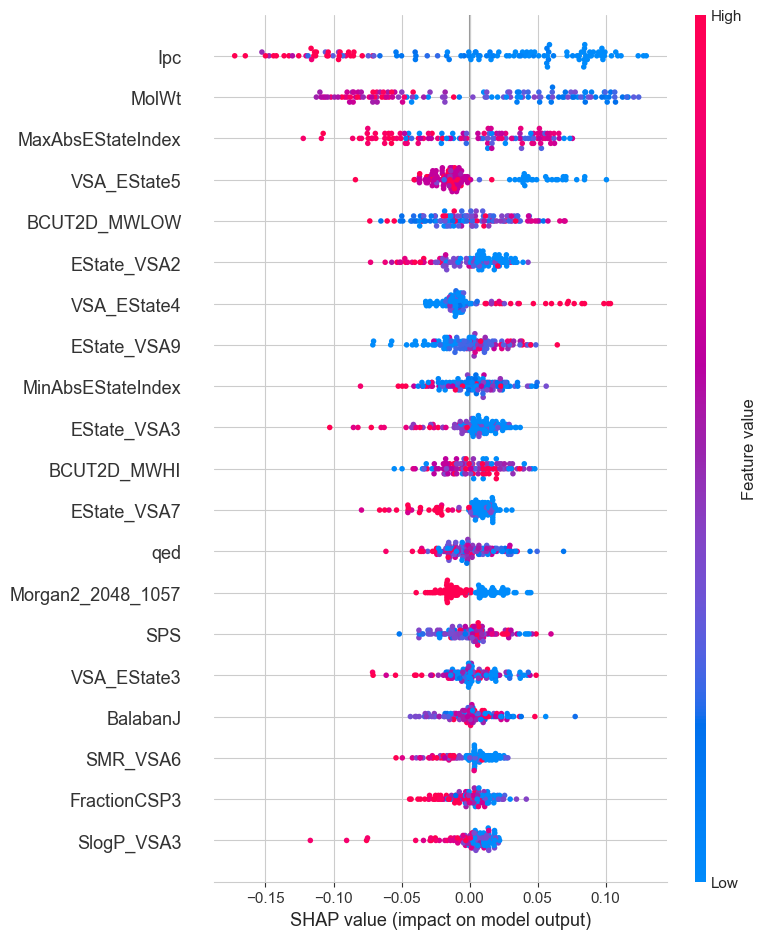


Top 10 SHAP features:
Ipc                  0.072785
MolWt                0.065923
MaxAbsEStateIndex    0.041181
VSA_EState5          0.026139
BCUT2D_MWLOW         0.024079
EState_VSA2          0.019234
VSA_EState4          0.018982
EState_VSA9          0.018369
MinAbsEStateIndex    0.018141
EState_VSA3          0.017160

Top 10 K-Best features:
Ipc                  40.738225
MolWt                31.851188
Morgan2_2048_80      14.409515
EState_VSA3          13.547252
BCUT2D_MWLOW         12.884055
EState_VSA2           8.976080
EState_VSA7           7.943538
VSA_EState5           7.460025
Morgan2_2048_1057     6.416426
RDK_2048_562          5.730300

Top 10 Lasso features:
Ipc                  1.850382
VSA_EState4          1.175219
MinAbsEStateIndex    0.831102
MolWt                0.729250
PEOE_VSA14           0.716829
EState_VSA7          0.686804
EState_VSA2          0.619304
VSA_EState5          0.459948
Morgan2_2048_80      0.459768
EState_VSA3          0.446921


In [49]:
import shap
from sklearn.feature_selection import mutual_info_classif


# === 2. SHAP Importance ===
# SHAP ti ukazuje, ako každý príznak (MACCS bit) prispieva ku konečnej predikcii.
# Je to najinterpretovateľnejšia metóda (globálne aj lokálne).
f = lambda X: base_model.predict_proba(X)[:, 1]

explainer = shap.Explainer(f, X_train)
shap_result = explainer(X_train, max_evals=2 * X_train.shape[1] + 50)

shap_values = shap_result.values
shap_importance = np.abs(shap_values).mean(axis=0)

shap_features = pd.Series(shap_importance, index=X_train.columns).sort_values(ascending=False)


# === 3. Mutual Information (MI) ===
# MI meria, koľko informácie nesie každý príznak o cieľovej triede.
# Je veľmi stabilná metóda pre malé datasety a zmiešané typy príznakov.
mi_scores = mutual_info_classif(X_train, y_train, discrete_features='auto', random_state=42)

mi_features = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)


# === 4. ANOVA F-score (SelectKBest) ===
# ANOVA porovnáva priemerné hodnoty príznakov medzi triedami.
# Je to čistý štatistický pohľad – nezávislý od modelu.
kbest = SelectKBest(score_func=f_classif, k='all')
kbest.fit(X_train, y_train)
kbest_scores = pd.Series(kbest.scores_, index=X_train.columns).fillna(0)
kbest_features = kbest_scores.sort_values(ascending=False)

# === 5. Lasso Logistic Regression (L1 koeficienty) ===
# Lasso dáva lineárny pohľad na dôležitosť príznakov – veľké koeficienty = dôležitý príznak.
# Veľkou výhodou je, že zriedi nepotrebné príznaky (robí sparse model).
lasso = LogisticRegression(
    penalty='l1',
    C=1.0,
    solver='liblinear',
    max_iter=5000
)
lasso.fit(X_train, y_train)

lasso_importance = pd.Series(np.abs(lasso.coef_).ravel(), index=X_train.columns)
lasso_features = lasso_importance.sort_values(ascending=False)

# === 6. vizualizácia ===
shap.summary_plot(shap_values, X_train)

# Print best features for each method
print("\nTop 10 SHAP features:")
print(shap_features.head(10).to_string())
print("\nTop 10 K-Best features:")
print(kbest_features.head(10).to_string())
print("\nTop 10 Lasso features:")
print(lasso_features.head(10).to_string())

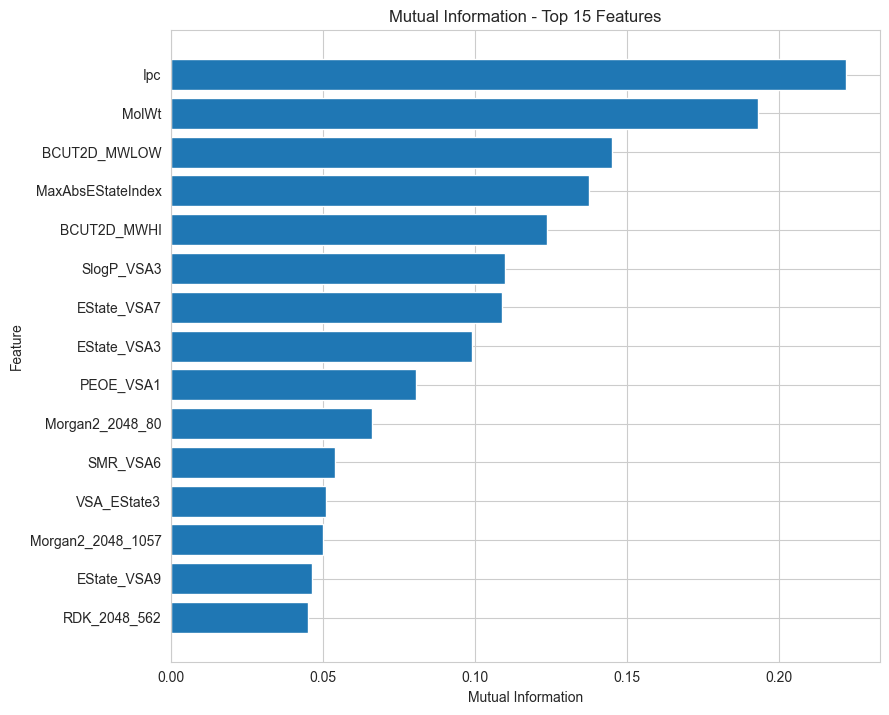

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

# 1) Mutual Information scores
mi_scores = mutual_info_classif(
    X_train, y_train,
    discrete_features="auto",
    random_state=42
)

mi_features = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

# 2) "summary plot" style: top-N MI features
top_n = 15  # поменяй как нужно
top_mi = mi_features.head(top_n).sort_values(ascending=True)  # для красивого горизонтального barh

plt.figure(figsize=(9, 0.35 * top_n + 2))
plt.barh(top_mi.index, top_mi.values)
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title(f"Mutual Information - Top {top_n} Features")
plt.tight_layout()
plt.show()

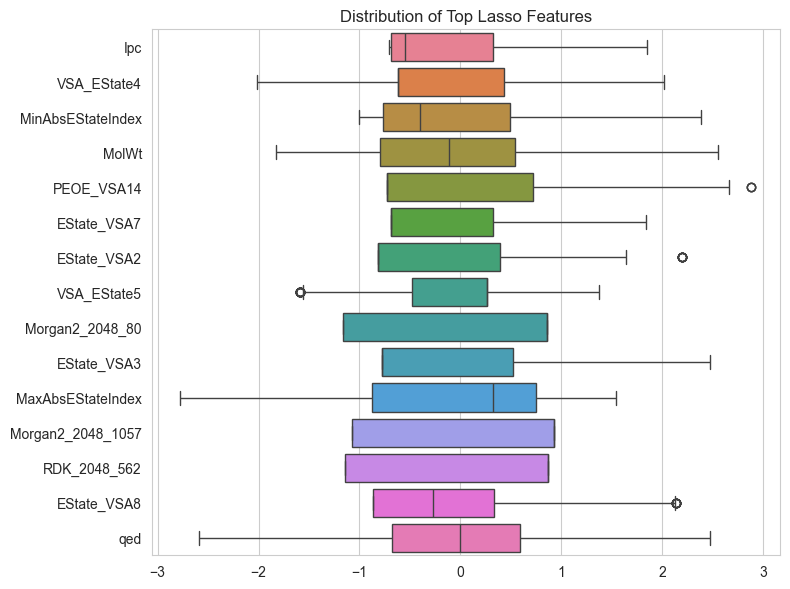

In [51]:
import seaborn as sns

top_feats = lasso_features.head(15).index

plt.figure(figsize=(8,6))

sns.boxplot(
    data=X_train[top_feats],
    orient="h"
)

plt.title("Distribution of Top Lasso Features")
plt.tight_layout()
plt.show()

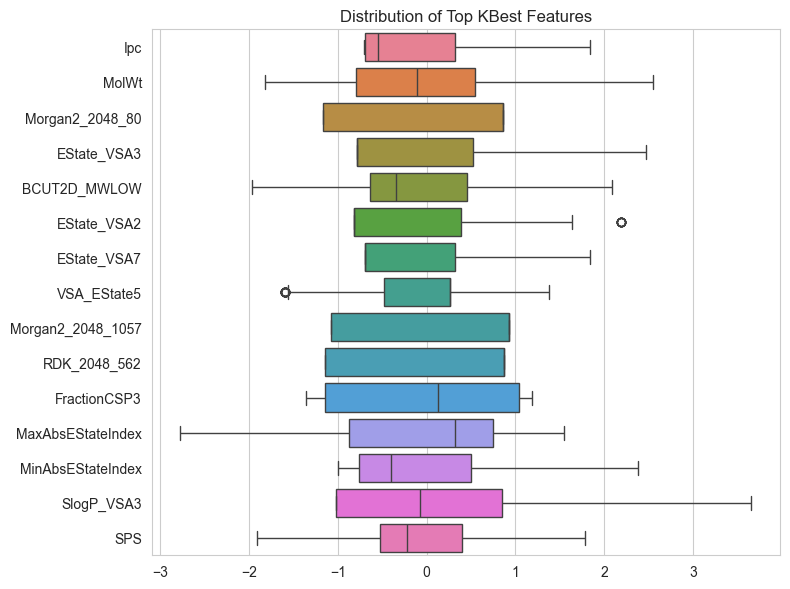

In [63]:
import seaborn as sns

top_feats = kbest_features.head(15).index

plt.figure(figsize=(8,6))

sns.boxplot(
    data=X_train[top_feats],
    orient="h"
)

plt.title("Distribution of Top KBest Features")
plt.tight_layout()
plt.show()



## Evaluate Feature Method

In [53]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

def evaluate_rf_feature_method(method_name, feature_ranking, X_train, y_train, rf_model):
    """
    Универсальная функция кросс-валидации для Random Forest.
    method_name: 'SHAP', 'RF', 'KBest', 'Lasso'
    feature_ranking: pd.Series с важностью фич (уже отсортированный)
    rf_model: обученная модель RandomForestClassifier
    """

    print(f"\n===== Evaluating {method_name} feature ranking =====")

    results = []
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Цикл top-N: 5, 10, 15, ..., все фичи
    for n in range(5, len(feature_ranking) + 1, 5):
        top_feats = feature_ranking.head(n).index.tolist()

        # Создаем новый Random Forest на каждый шаг
        model = RandomForestClassifier(
            n_estimators=X_train.shape[1],
            random_state=42,
            max_depth=4,
            min_samples_split=6,
            min_samples_leaf=3,
            max_features="sqrt",
            class_weight="balanced"
        )

        # Cross-validation
        cv_res = cross_validate(
            model,
            X_train[top_feats],
            y_train,
            cv=kf,
            scoring={"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"},
            n_jobs=-1,
            return_train_score=False
        )

        mean_acc = cv_res["test_accuracy"].mean()
        mean_f1 = cv_res["test_f1"].mean()
        mean_auc = cv_res["test_roc_auc"].mean()

        results.append((n, mean_acc, mean_f1, mean_auc))

    # Таблица
    res_df = pd.DataFrame(results, columns=["Top_N", "CV_Accuracy", "CV_F1", "CV_ROC_AUC"])

    # Лучший N по F1
    best = res_df.iloc[res_df["CV_F1"].idxmax()]
    best_n = int(best.Top_N)

    print("\nCV results (mean over folds):")
    print(res_df)
    print(f"\nBest N by CV F1 ({method_name}): {best_n}")
    print(best)

    # График
    plt.figure(figsize=(7, 4))
    plt.plot(res_df["Top_N"], res_df["CV_Accuracy"], label="CV Accuracy")
    plt.plot(res_df["Top_N"], res_df["CV_F1"], label="CV F1")
    plt.plot(res_df["Top_N"], res_df["CV_ROC_AUC"], label="CV ROC AUC")
    plt.xlabel(f"Number of top {method_name} features")
    plt.ylabel("Mean CV score")
    plt.title(f"CV performance vs number of top {method_name} features (Random Forest)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    return best_n, res_df


===== Evaluating SHAP feature ranking =====

CV results (mean over folds):
   Top_N  CV_Accuracy     CV_F1  CV_ROC_AUC
0      5        0.704  0.664982    0.841333
1     10        0.728  0.699744    0.869333
2     15        0.752  0.725859    0.873333
3     20        0.752  0.721651    0.861333
4     25        0.752  0.717693    0.854667

Best N by CV F1 (SHAP): 15
Top_N          15.000000
CV_Accuracy     0.752000
CV_F1           0.725859
CV_ROC_AUC      0.873333
Name: 2, dtype: float64


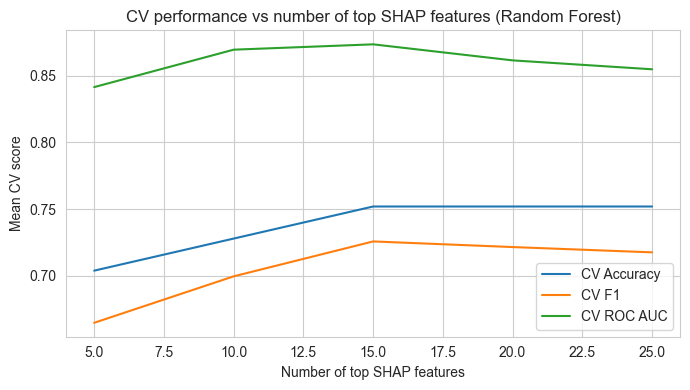


===== Evaluating MI feature ranking =====

CV results (mean over folds):
   Top_N  CV_Accuracy     CV_F1  CV_ROC_AUC
0      5        0.768  0.737077    0.865333
1     10        0.744  0.709433    0.853333
2     15        0.768  0.735383    0.886667
3     20        0.768  0.732088    0.873333
4     25        0.728  0.696932    0.861333

Best N by CV F1 (MI): 5
Top_N          5.000000
CV_Accuracy    0.768000
CV_F1          0.737077
CV_ROC_AUC     0.865333
Name: 0, dtype: float64


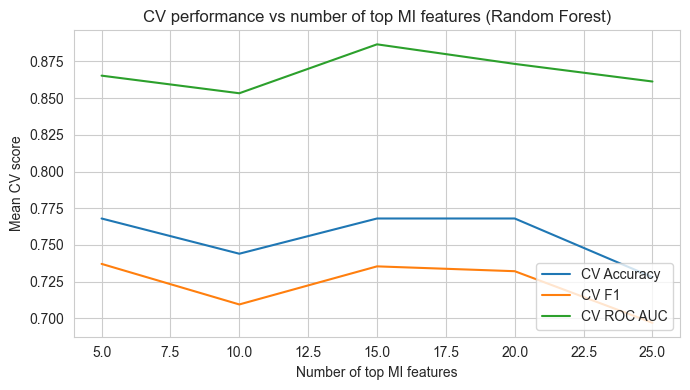


===== Evaluating KBest feature ranking =====

CV results (mean over folds):
   Top_N  CV_Accuracy     CV_F1  CV_ROC_AUC
0      5        0.712  0.683393    0.837333
1     10        0.744  0.717714    0.825333
2     15        0.728  0.703188    0.850667
3     20        0.680  0.640121    0.832000
4     25        0.688  0.654726    0.844000

Best N by CV F1 (KBest): 10
Top_N          10.000000
CV_Accuracy     0.744000
CV_F1           0.717714
CV_ROC_AUC      0.825333
Name: 1, dtype: float64


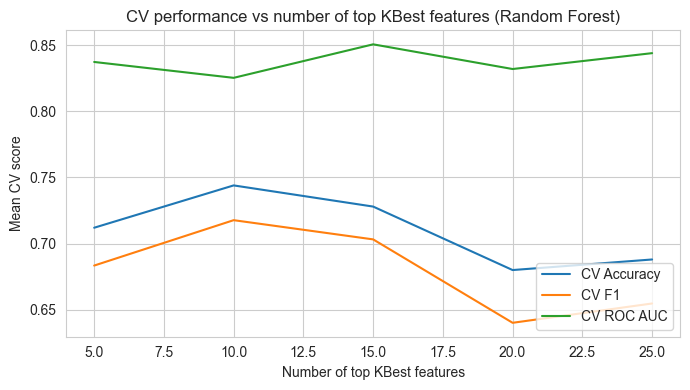


===== Evaluating Lasso feature ranking =====

CV results (mean over folds):
   Top_N  CV_Accuracy     CV_F1  CV_ROC_AUC
0      5        0.784  0.762130    0.858667
1     10        0.784  0.760421    0.868000
2     15        0.752  0.718592    0.874667
3     20        0.768  0.722254    0.873333
4     25        0.768  0.730130    0.874667

Best N by CV F1 (Lasso): 5
Top_N          5.000000
CV_Accuracy    0.784000
CV_F1          0.762130
CV_ROC_AUC     0.858667
Name: 0, dtype: float64


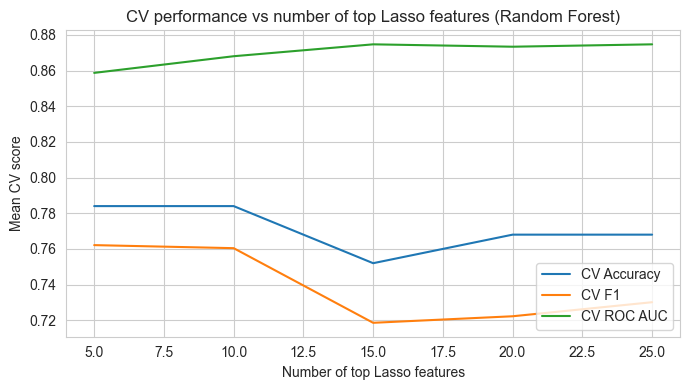

In [54]:


best_shap, shap_cv_table = evaluate_rf_feature_method(
    "SHAP", shap_features, X_train, y_train, base_model
)

best_mi, mi_cv_table = evaluate_rf_feature_method(
    "MI", mi_features, X_train, y_train, base_model
)

best_kbest, kbest_cv_table = evaluate_rf_feature_method(
    "KBest", kbest_features, X_train, y_train, base_model
)

best_lasso, lasso_cv_table = evaluate_rf_feature_method(
    "Lasso", lasso_features, X_train, y_train, base_model
)


## Train Model Features

In [57]:
from sklearn.metrics import precision_score, recall_score, f1_score

def train_final_rf_model(method_name, feature_ranking, best_n,
                         X_train, X_test, y_train, y_test):
    """
    Строит финальную Random Forest модель на лучших фичах,
    найденных методом SHAP / RF / KBest / Lasso.

    method_name: строка ('SHAP', 'RF', 'KBest', 'Lasso')
    feature_ranking: pd.Series — ранжированные фичи
    best_n: количество лучших фич из evaluate_rf_feature_method()
    """

    print(f"\n===== FINAL Random Forest model using {best_n} {method_name} features =====")

    # выбираем топ-N фич
    top_feats = feature_ranking.head(best_n).index.tolist()

    # создаём финальную Random Forest модель
    # final_model = RandomForestClassifier(
    #     n_estimators=best_n,      # число деревьев = число фич
    #     random_state=42,
    #     class_weight="balanced",
    #     max_depth=8,
    # )

    final_model = RandomForestClassifier(
        n_estimators=best_n,
        max_depth=5,          # было 8
        min_samples_split=5,  # было 2
        min_samples_leaf=3,   # было 1
        max_features="sqrt",
        class_weight="balanced",
        random_state=42
    )

    # обучение модели
    final_model.fit(X_train[top_feats], y_train)

    # предсказание

    y_pred = final_model.predict(X_test[top_feats])
    y_prob = final_model.predict_proba(X_test[top_feats])[:, 1]

    # считаем метрики
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)

    # выводим отчёт
    print(f"\nFinal model performance ({method_name}) on TEST:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 score:  {f1:.4f}")
    print(f"ROC AUC:   {auc:.4f}")

    log_result(
    method_name,
    model_type="Baseline_RF",
    n_features=best_n,
    metrics={
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": auc
    },
    params={
        "n_estimators": X_train.shape[1],
        "class_weight": "balanced"
    },
    stage="final"
)


    # 7возвращаем модель и метрики
    return final_model, {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": auc,
        "Top_Features": top_feats
    }


In [75]:

final_shap_model, shap_metrics = train_final_rf_model(
    "SHAP", shap_features, best_shap, X_train, X_test, y_train, y_test
)

final_mi_model, mi_metrics = train_final_rf_model(
    "MI", mi_features, best_mi, X_train, X_test, y_train, y_test
)

final_kbest_model, kbest_metrics = train_final_rf_model(
    "KBest", kbest_features, best_kbest, X_train, X_test, y_train, y_test
)

final_lasso_model, lasso_metrics = train_final_rf_model(
    "Lasso", lasso_features, best_lasso, X_train, X_test, y_train, y_test
)



===== FINAL Random Forest model using 15 SHAP features =====

Final model performance (SHAP) on TEST:
Accuracy:  0.8125
Precision: 0.7692
Recall:    0.7692
F1 score:  0.7692
ROC AUC:   0.8340

===== FINAL Random Forest model using 5 MI features =====

Final model performance (MI) on TEST:
Accuracy:  0.7812
Precision: 0.7500
Recall:    0.6923
F1 score:  0.7200
ROC AUC:   0.8057

===== FINAL Random Forest model using 10 KBest features =====

Final model performance (KBest) on TEST:
Accuracy:  0.8438
Precision: 0.7857
Recall:    0.8462
F1 score:  0.8148
ROC AUC:   0.8219

===== FINAL Random Forest model using 5 Lasso features =====

Final model performance (Lasso) on TEST:
Accuracy:  0.6875
Precision: 0.6667
Recall:    0.4615
F1 score:  0.5455
ROC AUC:   0.7348


In [76]:
print("n_estimators:", final_kbest_model.n_estimators)
print("max_depth:", final_kbest_model.max_depth)
print("min_samples_split:", final_kbest_model.min_samples_split)
print("min_samples_leaf:", final_kbest_model.min_samples_leaf)
print("max_features:", final_kbest_model.max_features)

n_estimators: 10
max_depth: 5
min_samples_split: 5
min_samples_leaf: 3
max_features: sqrt



## Optuna

In [77]:
def tune_rf_optuna(method_name, feature_ranking, best_n,
                   X_train, X_test, y_train, y_test, n_trials=50):

    top_feats = feature_ranking.head(best_n).index.tolist()
    X_train_fs = X_train[top_feats]
    X_test_fs  = X_test[top_feats]

    optuna.logging.set_verbosity(optuna.logging.ERROR)

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 20, 120),
            "max_depth": trial.suggest_int("max_depth", 4, 8),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 6),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 4),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", 0.1, 0.2]),
            "bootstrap": True,
            "class_weight": "balanced",
            "random_state": 42,
            "n_jobs": -1,
        }

        model = RandomForestClassifier(**params)

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        auc = cross_val_score(
            model, X_train_fs, y_train,
            cv=cv, scoring="roc_auc", n_jobs=-1
        ).mean()

        return auc

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params = study.best_params

    final_model = RandomForestClassifier(
        **best_params,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    final_model.fit(X_train_fs, y_train)

    y_pred = final_model.predict(X_test_fs)
    y_prob = final_model.predict_proba(X_test_fs)[:, 1]

    return {
        "Method": method_name,
        "Model": "RandomForest",
        "Feature_Ranking": feature_ranking,
        "Best_N": best_n,
        "AUC": roc_auc_score(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Params": study.best_params,
        "Top_Features": top_feats
    }




## Result

In [90]:
methods = {
    "SHAP": (shap_features, best_shap),
    "MI": (mi_features, best_mi),
    "KBest": (kbest_features, best_kbest),
    "Lasso": (lasso_features, best_lasso),
}

rf_rows = []

for name, (ranking, best_n) in methods.items():

    rf_rows.append(
        tune_rf_optuna(name, ranking, best_n,
                       X_train, X_test, y_train, y_test)
    )


# Таблицы
rf_results_df = pd.DataFrame(rf_rows)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [91]:
rf_results_df

,Method,Model,Feature_Ranking,Best_N,AUC,Accuracy,Precision,Recall,F1,Params,Top_Features
0,SHAP,RandomForest,Ipc 0.072785 MolWt ...,15,0.846154,0.78125,0.750000,0.692308,0.720000,"{'n_estimators': 71, 'max_depth': 8, 'min_samp...","[Ipc, MolWt, MaxAbsEStateIndex, VSA_EState5, B..."
1,MI,RandomForest,Ipc 0.222020 MolWt ...,5,0.813765,0.71875,0.700000,0.538462,0.608696,"{'n_estimators': 116, 'max_depth': 6, 'min_sam...","[Ipc, MolWt, BCUT2D_MWLOW, MaxAbsEStateIndex, ..."
2,KBest,RandomForest,Ipc 40.738225 MolWt ...,10,0.825911,0.81250,0.818182,0.692308,0.750000,"{'n_estimators': 110, 'max_depth': 8, 'min_sam...","[Ipc, MolWt, Morgan2_2048_80, EState_VSA3, BCU..."
3,Lasso,RandomForest,Ipc 1.850382 VSA_EState4 ...,5,0.740891,0.71875,0.642857,0.692308,0.666667,"{'n_estimators': 60, 'max_depth': 8, 'min_samp...","[Ipc, VSA_EState4, MinAbsEStateIndex, MolWt, P..."


In [92]:
kbest_metrics = rf_results_df[rf_results_df["Method"] == "KBest"].iloc[0]

print({
    "Method": kbest_metrics["Method"],
    "Model": kbest_metrics["Model"],
    "Best_N": kbest_metrics["Best_N"],
    "AUC": kbest_metrics["AUC"],
    "Accuracy": kbest_metrics["Accuracy"],
    "Precision": kbest_metrics["Precision"],
    "Recall": kbest_metrics["Recall"],
    "F1": kbest_metrics["F1"],
    "Params": kbest_metrics["Params"]
})

{'Method': 'KBest', 'Model': 'RandomForest', 'Best_N': np.int64(10), 'AUC': np.float64(0.8259109311740892), 'Accuracy': np.float64(0.8125), 'Precision': np.float64(0.8181818181818182), 'Recall': np.float64(0.6923076923076923), 'F1': np.float64(0.75), 'Params': {'n_estimators': 110, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.1}}


## Dinamic


=== Testing top 5 Kbest features ===
Best parameters: {'n_estimators': np.int64(100), 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': 4, 'bootstrap': False}
Accuracy: 0.781 | ROC-AUC: 0.820

=== Testing top 6 Kbest features ===
Best parameters: {'n_estimators': np.int64(120), 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 0.3, 'max_depth': 4, 'bootstrap': False}
Accuracy: 0.812 | ROC-AUC: 0.834

=== Testing top 7 Kbest features ===
Best parameters: {'n_estimators': np.int64(20), 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 3, 'bootstrap': True}
Accuracy: 0.750 | ROC-AUC: 0.814

=== Testing top 8 Kbest features ===
Best parameters: {'n_estimators': np.int64(20), 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_depth': 7, 'bootstrap': True}
Accuracy: 0.812 | ROC-AUC: 0.818

=== Testing top 9 Kbest features ===
Best parameters: {'n_estimators': np.int64(100), 'min_samples_

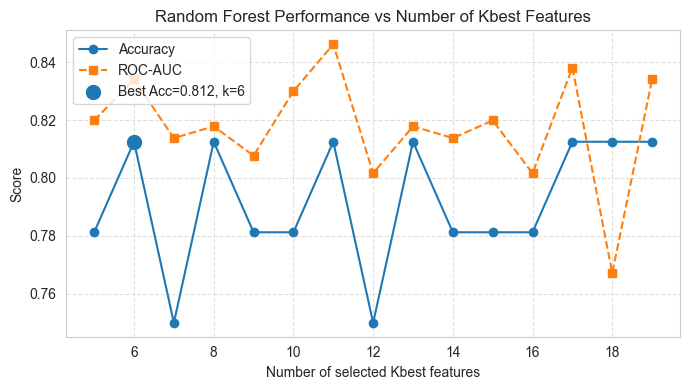


Best Accuracy = 0.812, ROC-AUC = 0.834, k = 6


In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score

# Ранжирование признаков (Kbest)
ranking = kbest_features   # Series: feature -> importance

# Гиперпараметры для Random Forest
param_dist = {
    "n_estimators": np.arange(20, 160, 20),
    "max_depth": [3, 4, 5, 6, 7, None],
    "min_samples_split": [2, 3, 4, 5, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4, 5],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],
    "bootstrap": [True, False],
}

results = []

# Sweep по числу признаков
for k in range(5, 20, 1):
    print(f"\n=== Testing top {k} Kbest features ===")

    # Выбор top-k фичей
    top_feats = ranking.head(k).index.tolist()
    X_train_sel = X_train[top_feats]
    X_test_sel = X_test[top_feats]

    # Модель
    rf_clf = RandomForestClassifier(
        random_state=42,
        max_depth=5,          # было 8
        min_samples_split=5,  # было 2
        min_samples_leaf=3,   # было 1
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1
    )

    # RandomizedSearchCV
    search = RandomizedSearchCV(
        estimator=rf_clf,
        param_distributions=param_dist,
        n_iter=60,
        scoring="accuracy",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    search.fit(X_train_sel, y_train)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test_sel)
    y_prob = best_model.predict_proba(X_test_sel)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append((k, acc, auc))

    print(f"Best parameters: {search.best_params_}")
    print(f"Accuracy: {acc:.3f} | ROC-AUC: {auc:.3f}")

# Анализ результатов
results = np.array(results)
feature_counts = results[:, 0]
accuracies = results[:, 1]
auc_scores = results[:, 2]

# Лучший по Accuracy
best_index = np.argmax(accuracies)
best_k = int(feature_counts[best_index])
best_acc = accuracies[best_index]
best_auc = auc_scores[best_index]

# Графики
plt.figure(figsize=(7, 4))
plt.plot(feature_counts, accuracies, 'o-', label='Accuracy')
plt.plot(feature_counts, auc_scores, 's--', label='ROC-AUC')
plt.scatter(best_k, best_acc, s=100, zorder=5,
            label=f'Best Acc={best_acc:.3f}, k={best_k}')
plt.title('Random Forest Performance vs Number of Kbest Features')
plt.xlabel('Number of selected Kbest features')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBest Accuracy = {best_acc:.3f}, ROC-AUC = {best_auc:.3f}, k = {best_k}")


In [86]:
#from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("\n===== Overfitting check (TRAIN vs TEST) =====")
final_model = final_kbest_model
top_feats = kbest_metrics["Top_Features"]

# ===== TRAIN =====
y_train_pred = final_model.predict(X_train[top_feats])
y_train_prob = final_model.predict_proba(X_train[top_feats])[:, 1]

train_acc  = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred)
train_rec  = recall_score(y_train, y_train_pred)
train_f1   = f1_score(y_train, y_train_pred)
train_auc  = roc_auc_score(y_train, y_train_prob)

print("\nTRAIN performance:")
print(f"Accuracy:  {train_acc:.4f}")
print(f"Precision: {train_prec:.4f}")
print(f"Recall:    {train_rec:.4f}")
print(f"F1 score:  {train_f1:.4f}")
print(f"ROC AUC:   {train_auc:.4f}")


# ===== TEST =====
y_test_pred = final_model.predict(X_test[top_feats])
y_test_prob = final_model.predict_proba(X_test[top_feats])[:, 1]

test_acc  = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec  = recall_score(y_test, y_test_pred)
test_f1   = f1_score(y_test, y_test_pred)
test_auc  = roc_auc_score(y_test, y_test_prob)

print("\nTEST performance:")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1 score:  {test_f1:.4f}")
print(f"ROC AUC:   {test_auc:.4f}")


===== Overfitting check (TRAIN vs TEST) =====

TRAIN performance:
Accuracy:  0.8960
Precision: 0.8136
Recall:    0.9600
F1 score:  0.8807
ROC AUC:   0.9680

TEST performance:
Accuracy:  0.8438
Precision: 0.7857
Recall:    0.8462
F1 score:  0.8148
ROC AUC:   0.8219



===== Learning Curve (Overfitting check) =====

Train F1 scores: [0.82683375 0.86539589 0.87330483 0.87930356 0.85078498 0.85294988]
Validation F1 scores: [0.54201709 0.63519364 0.60333333 0.67972607 0.61289439 0.58384677]


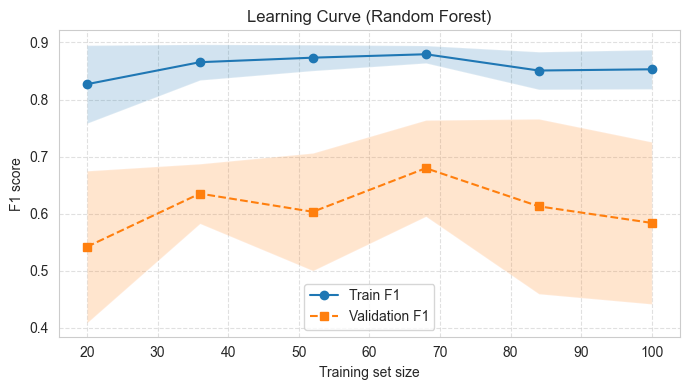

In [93]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

print("\n===== Learning Curve (Overfitting check) =====")

# используем те же признаки, что и в финальной модели
top_feats = kbest_features.head(6).index.tolist()
model = final_kbest_model

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train[top_feats],
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    train_sizes=np.linspace(0.2, 1.0, 6),
    shuffle=True,
    random_state=42
)

# средние значения
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# стандартное отклонение
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

print("\nTrain F1 scores:", train_mean)
print("Validation F1 scores:", val_mean)

# ===== график =====
plt.figure(figsize=(7,4))

plt.plot(train_sizes, train_mean, 'o-', label="Train F1")
plt.plot(train_sizes, val_mean, 's--', label="Validation F1")

plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2)

plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.2)

plt.xlabel("Training set size")
plt.ylabel("F1 score")
plt.title("Learning Curve (Random Forest)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [98]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

print("\n===== Y-randomization test =====")

n_iter = 100
random_auc = []

top_feats = kbest_metrics["Top_Features"]

for i in range(n_iter):

    # случайная перестановка меток
    y_rand = np.random.permutation(y_train)

    model = RandomForestClassifier(
        n_estimators=best_kbest,
        max_depth=4,
        min_samples_split=6,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced",
        random_state=i
    )

    model.fit(X_train[top_feats], y_rand)

    y_prob = model.predict_proba(X_test[top_feats])[:,1]

    auc = roc_auc_score(y_test, y_prob)
    random_auc.append(auc)

print("Mean random AUC:", np.mean(random_auc))
print("Std random AUC:", np.std(random_auc))


===== Y-randomization test =====
Mean random AUC: 0.5139676113360324
Std random AUC: 0.13715721451393764


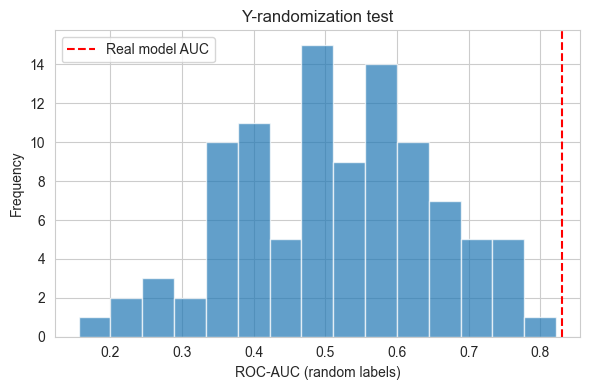

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(random_auc, bins=15, alpha=0.7)
plt.axvline(0.83, color='red', linestyle='--', label="Real model AUC")

plt.xlabel("ROC-AUC (random labels)")
plt.ylabel("Frequency")
plt.title("Y-randomization test")

plt.legend()
plt.tight_layout()
plt.show()

In [119]:
final_table = save_results_table("../all_results.xlsx")
print(final_table)

Saved full results table to ../all_results.xlsx
  Method        Model  Stage  Top_Features  Accuracy  Precision    Recall  \
0   SHAP  Baseline_RF  final            25   0.81250   0.769231  0.769231   
1     MI  Baseline_RF  final            20   0.75000   0.727273  0.615385   
2  KBest  Baseline_RF  final            25   0.81250   0.769231  0.769231   
3  Lasso  Baseline_RF  final             5   0.75000   0.692308  0.692308   
4   SHAP  Baseline_RF  final            25   0.78125   0.800000  0.615385   
5     MI  Baseline_RF  final            20   0.75000   0.727273  0.615385   
6  KBest  Baseline_RF  final            25   0.81250   0.818182  0.692308   
7  Lasso  Baseline_RF  final             5   0.71875   0.700000  0.538462   

         F1   ROC_AUC  Param_n_estimators Param_class_weight  
0  0.769231  0.854251                  28           balanced  
1  0.666667  0.821862                  28           balanced  
2  0.769231  0.846154                  28           balanced  
3  0.6